In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [3]:
conn = sqlite3.connect('../AdventureWorks.db')

internet = pd.read_sql("""
    SELECT 
        s.SalesAmount,
        s.OrderQuantity,
        s.UnitPrice,
        s.DiscountAmount,
        s.TotalProductCost,
        s.TaxAmt,
        s.Freight,
        s.UnitPriceDiscountPct,
        s.OrderDateKey,
        s.SalesTerritoryKey,
        s.PromotionKey,
        'Internet' as Source
    FROM FactInternetSales s
""", conn)

reseller = pd.read_sql("""
    SELECT 
        s.SalesAmount,
        s.OrderQuantity,
        s.UnitPrice,
        s.DiscountAmount,
        s.TotalProductCost,
        s.TaxAmt,
        s.Freight,
        s.UnitPriceDiscountPct,
        s.OrderDateKey,
        s.SalesTerritoryKey,
        s.PromotionKey,
        'Reseller' as Source
    FROM FactResellerSales s
""", conn)

df = pd.concat([internet, reseller], ignore_index=True)
conn.close()
print(df.shape)
df.head()

(119218, 12)


,SalesAmount,OrderQuantity,UnitPrice,DiscountAmount,TotalProductCost,TaxAmt,Freight,UnitPriceDiscountPct,OrderDateKey,SalesTerritoryKey,PromotionKey,Source
0,3578.2700,1,3578.2700,0.0,2171.2942,286.2616,89.4568,0.0,20101229,6,1,Internet
1,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,7,1,Internet
2,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,1,1,Internet
3,699.0982,1,699.0982,0.0,413.1463,55.9279,17.4775,0.0,20101229,4,1,Internet
4,3399.9900,1,3399.9900,0.0,1912.1544,271.9992,84.9998,0.0,20101229,9,1,Internet


In [10]:
# Extract month and year from OrderDateKey (format: YYYYMMDD)
df['Year'] = df['OrderDateKey'].astype(str).str[:4].astype(int)
df['Month'] = df['OrderDateKey'].astype(str).str[4:6].astype(int)

# Encode Source column
df['IsInternet'] = (df['Source'] == 'Internet').astype(int)

# Drop original columns not needed for regression
df_model = df.drop(columns=[
    'OrderDateKey', 
    'Source',
    'TotalProductCost',  # derived from SalesAmount
    'TaxAmt',            # derived from SalesAmount
    'Freight'            # derived from SalesAmount
])

print(df_model.dtypes)
df_model.describe()

SalesAmount             float64
OrderQuantity             int64
UnitPrice               float64
DiscountAmount          float64
UnitPriceDiscountPct    float64
SalesTerritoryKey         int64
PromotionKey              int64
Year                      int64
Month                     int64
IsInternet                int64
dtype: object


,SalesAmount,OrderQuantity,UnitPrice,DiscountAmount,UnitPriceDiscountPct,SalesTerritoryKey,PromotionKey,Year,Month,IsInternet
count,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000,119218.000000
mean,900.473799,2.245106,466.116090,4.362494,0.002682,5.409854,1.158005,2012.591085,6.503213,0.506618
std,1687.844691,2.476633,755.770042,62.777211,0.023598,2.835529,1.188997,0.703747,3.518390,0.499958
min,1.374000,1.000000,1.328200,0.000000,0.000000,1.000000,1.000000,2010.000000,1.000000,0.000000
25%,24.990000,1.000000,21.490000,0.000000,0.000000,4.000000,1.000000,2012.000000,3.000000,0.000000
50%,127.800000,1.000000,49.990000,0.000000,0.000000,6.000000,1.000000,2013.000000,7.000000,1.000000
75%,1120.490000,3.000000,600.262500,0.000000,0.000000,8.000000,1.000000,2013.000000,10.000000,1.000000
max,27893.619000,44.000000,3578.270000,4005.237600,0.400000,10.000000,16.000000,2014.000000,12.000000,1.000000


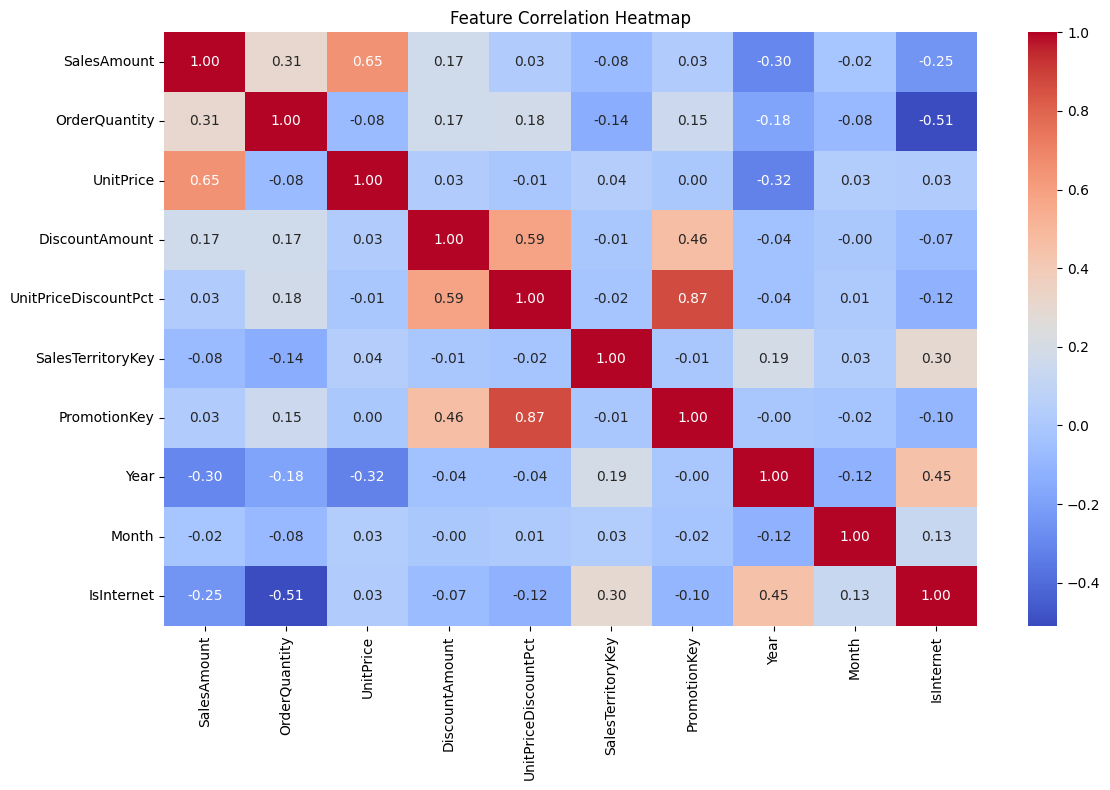

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [12]:
def run_regression(df, target):
    X = df.drop(columns=['SalesAmount', 'OrderQuantity'])
    y = df[target]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # Sklearn model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*40}")
    print(f"Target: {target}")
    print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
    print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    
    # Statsmodels for p-values
    X_sm = sm.add_constant(X_scaled)
    sm_model = sm.OLS(y, X_sm).fit()
    print(sm_model.summary())
    
    # Feature importance plot
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
    plt.title(f'Feature Coefficients — {target}')
    plt.tight_layout()
    plt.savefig(f'regression_{target}.png')
    plt.show()
    
    return model, scaler


Target: SalesAmount
R² Score:  0.5233
RMSE:      1179.4543
                            OLS Regression Results                            
Dep. Variable:            SalesAmount   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                 1.615e+04
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        20:13:55   Log-Likelihood:            -1.0113e+06
No. Observations:              119218   AIC:                         2.023e+06
Df Residuals:                  119209   BIC:                         2.023e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

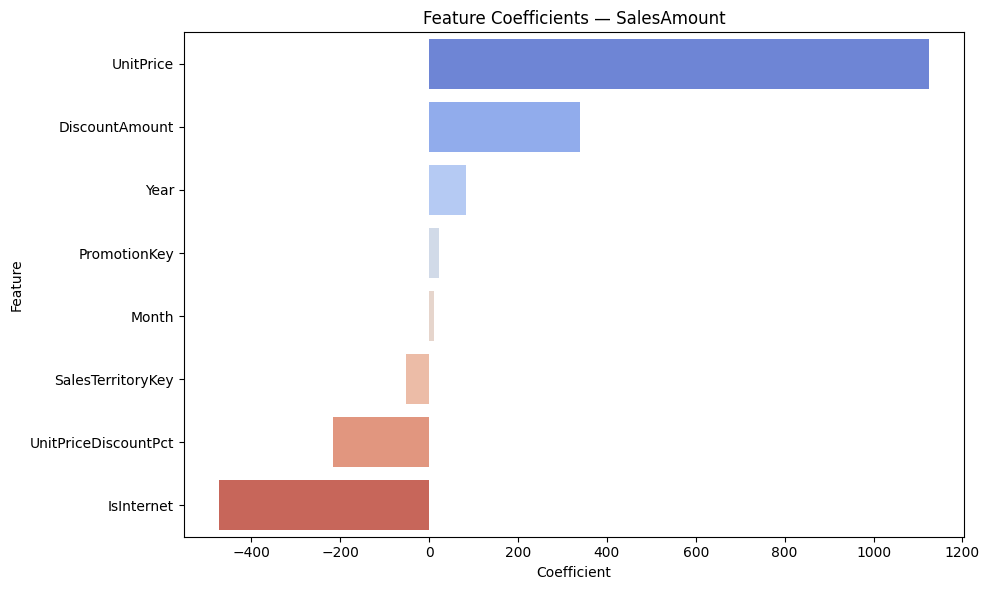


Target: OrderQuantity
R² Score:  0.2859
RMSE:      2.1230
                            OLS Regression Results                            
Dep. Variable:          OrderQuantity   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     5957.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        20:13:55   Log-Likelihood:            -2.5723e+05
No. Observations:              119218   AIC:                         5.145e+05
Df Residuals:                  119209   BIC:                         5.146e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

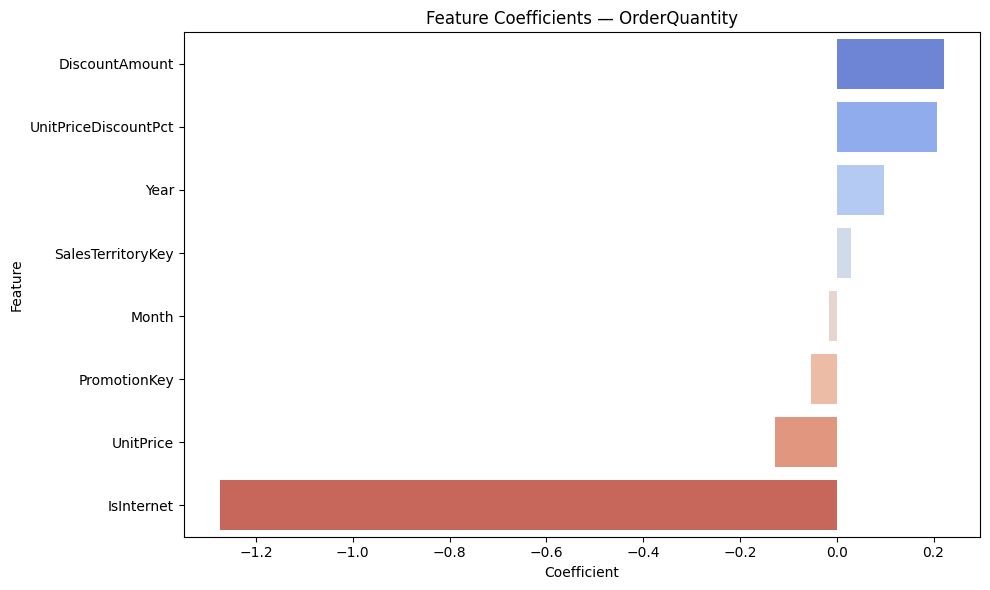

In [13]:
model_sales, scaler_sales = run_regression(df_model, 'SalesAmount')
model_qty, scaler_qty = run_regression(df_model, 'OrderQuantity')